In [1]:
import numpy as np, curvedsky as cs, plottools as pl, cmb as CMB, cosmology, healpy as hp, local, tools_cmb
from matplotlib.pyplot import *
import warnings
warnings.filterwarnings("ignore")
ac2rad  = np.pi/10800.
deg2rad = np.pi/180.
Tcmb  = CMB.Tcmb    # CMB temperature

In [2]:
lmax = 2048
l = np.linspace(0,lmax,lmax+1)

In [3]:
aobj = local.init_analysis(freq='143',ascale=0.5)

In [4]:
wind = local.set_mask(aobj.famask)[0]

In [5]:
mask = hp.fitsfunc.read_map('../data/plk_biref/mask/COM_Mask_Lensing_2048_R3.00_a1.0deg.fits')

In [24]:
#W = mask * wind
W = wind

In [25]:
tmap = W*tools_cmb.reduc_map(aobj.dtype,aobj.fimap['s'][0],field=0)

In [26]:
Tmap = W*tools_cmb.reduc_map(aobj.dtype,aobj.fimap['s'][1],field=0)

In [27]:
Nmap = W*tools_cmb.reduc_map(aobj.dtype,aobj.fimap['n'][1],field=0)

In [28]:
talm = cs.utils.hp_map2alm(2048,lmax,lmax,tmap)

In [29]:
Talm = cs.utils.hp_map2alm(2048,lmax,lmax,Tmap)
Nalm = cs.utils.hp_map2alm(2048,lmax,lmax,Nmap)

In [30]:
cl = cs.utils.alm2cl(lmax,talm)
Sl = cs.utils.alm2cl(lmax,Talm)
Nl = cs.utils.alm2cl(lmax,Nalm)

In [31]:
ibl = np.exp(l*(l+1.)*(5.*ac2rad)**2/8./np.log(2.))

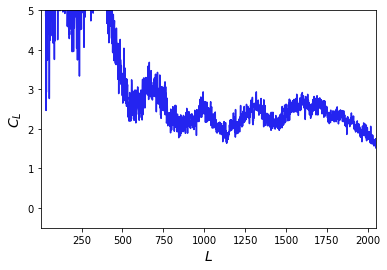

In [36]:
pl.plot_1dstyle(ymin=-.5,ymax=5.)
s = l*(l+1.)/2./np.pi
pl.plot_1dstyle(xmin=2,xmax=2048)
plot(l,(cl/(Sl+Nl)-1.))
#axhline(1,color='k')
#plot(l,(Sl+Nl))

In [15]:
qmap = tools_cmb.reduc_map(aobj.dtype,aobj.fimap['s'][0],field=1)
umap = tools_cmb.reduc_map(aobj.dtype,aobj.fimap['s'][0],field=2)

In [16]:
sQmap = tools_cmb.reduc_map(aobj.dtype,aobj.fimap['s'][1],field=1)
sUmap = tools_cmb.reduc_map(aobj.dtype,aobj.fimap['s'][1],field=2)
nQmap = tools_cmb.reduc_map(aobj.dtype,aobj.fimap['n'][1],field=1)
nUmap = tools_cmb.reduc_map(aobj.dtype,aobj.fimap['n'][1],field=2)

In [17]:
ealm, balm = cs.utils.hp_map2alm_spin(2048,lmax,lmax,2,qmap,umap)

In [18]:
Ealm, Balm = cs.utils.hp_map2alm_spin(2048,lmax,lmax,2,(sQmap+nQmap),(sUmap+nUmap))

In [19]:
ee = cs.utils.alm2cl(lmax,ealm)
bb = cs.utils.alm2cl(lmax,balm)
EE = cs.utils.alm2cl(lmax,Ealm)
BB = cs.utils.alm2cl(lmax,Balm)

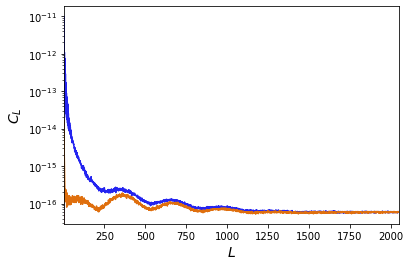

In [20]:
pl.plot_1dstyle(xmin=2,xmax=2048,ylog=True)
plot(ee)
plot(EE)

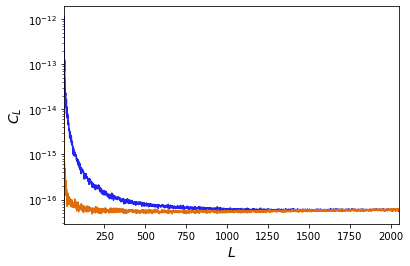

In [21]:
pl.plot_1dstyle(xmin=2,xmax=2048,ylog=True)
plot(bb)
plot(BB)